# Thompson Sampling

## Importing the libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [12]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')
N, d = dataset.shape

## Implementing Thompson Sampling

In [13]:
# import random
# N = 10000
# d = 10
# ads_selected = []
# numbers_of_rewards_1 = [0] * d
# numbers_of_rewards_0 = [0] * d
# total_reward = 0
# for n in range (0, N):
#     ad = 0
#     max_random = 0
#     for i in range(0, d):
#         random_beta = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)
#         if random_beta > max_random:
#             max_random = random_beta
#             ad = i
#     ads_selected.append(ad)
#     reward = dataset.values[n, ad]
#     if reward == 1:
#         numbers_of_rewards_1[ad] += 1
#     else:
#         numbers_of_rewards_0[ad] += 1
#     total_reward += reward


# ── Thompson Sampling ─────────────────────────────────────────────────────────
ads_selected      = []
rewards_1         = np.ones(d)   # successes + 1 (Beta prior starts at 1)
rewards_0         = np.ones(d)   # failures  + 1
total_reward      = 0

for n in range(N):
    # Draw a sample from each ad's Beta distribution and pick the best
    ad = np.argmax(np.random.beta(rewards_1, rewards_0))  # vectorized — no inner loop
    ads_selected.append(ad)

    # Observe reward and update Beta parameters
    reward = dataset.values[n, ad]
    rewards_1[ad] += reward        # success
    rewards_0[ad] += 1 - reward    # failure
    total_reward  += reward

# ── Results ───────────────────────────────────────────────────────────────────
best_ad = np.argmax(rewards_1 / (rewards_1 + rewards_0))
print(f"Total Reward      : {int(total_reward)}")
print(f"Best Ad (0-indexed): Ad {best_ad + 1}")
print(f"\nSelections per ad:")
for i in range(d):
    total_i  = rewards_1[i] + rewards_0[i] - 2        # subtract the prior
    avg      = (rewards_1[i] - 1) / total_i if total_i > 0 else 0
    print(f"  Ad {i+1}: {int(total_i):>5} times  |  Avg reward: {avg:.4f}")


Total Reward      : 2596
Best Ad (0-indexed): Ad 5

Selections per ad:
  Ad 1:    70 times  |  Avg reward: 0.1143
  Ad 2:    46 times  |  Avg reward: 0.0652
  Ad 3:    33 times  |  Avg reward: 0.0303
  Ad 4:    41 times  |  Avg reward: 0.0488
  Ad 5:  8951 times  |  Avg reward: 0.2690
  Ad 6:    25 times  |  Avg reward: 0.0000
  Ad 7:    58 times  |  Avg reward: 0.0862
  Ad 8:   680 times  |  Avg reward: 0.2353
  Ad 9:    72 times  |  Avg reward: 0.1250
  Ad 10:    24 times  |  Avg reward: 0.0000


## Visualising the results - Histogram

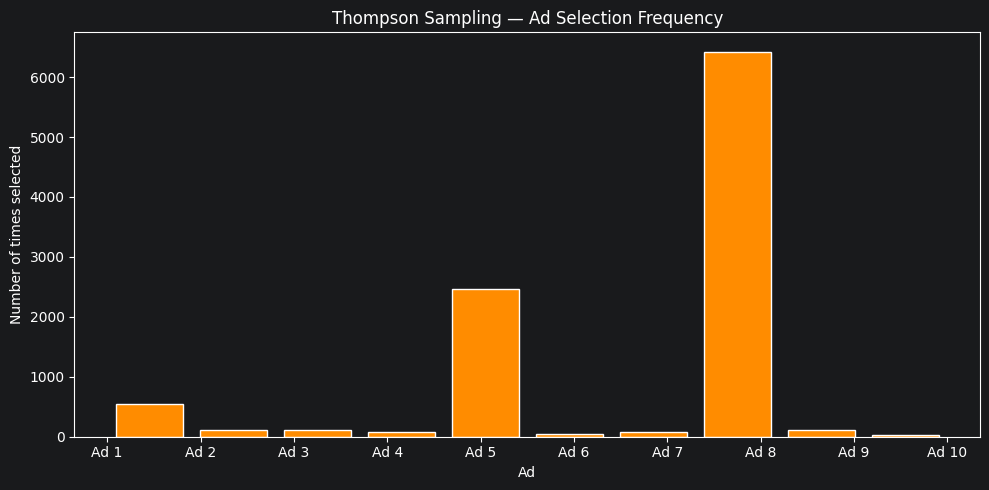

In [10]:
# plt.hist(ads_selected)
# plt.title('Histogram of ads selections')
# plt.xlabel('Ads')
# plt.ylabel('Number of times each ad was selected')
# plt.show()

plt.figure(figsize=(10, 5))
plt.hist(ads_selected, bins=d, rwidth=0.8, color='darkorange', edgecolor='white')
plt.title('Thompson Sampling — Ad Selection Frequency')
plt.xlabel('Ad')
plt.ylabel('Number of times selected')
plt.xticks(range(d), [f'Ad {i+1}' for i in range(d)])
plt.tight_layout()
plt.savefig('thompson_selections.png', dpi=150)
plt.show()
